In [1]:
! pip install optuna 

In [2]:
!pip install optuna-integration[xgboost]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 4.0 MB/s eta 0:00:00


In [3]:
import json
import numpy as np
import pandas as pd
import joblib
import optuna
import xgboost as xgb
from xgboost import XGBRegressor
from optuna.integration import XGBoostPruningCallback
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import os
from sklearn.metrics import mean_absolute_error
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv("/kaggle/input/datasets/aryansharmabf/delhi-aqi-prediction/delhi_2000_2025_extended.csv")

/kaggle/input/datasets/aryansharmabf/delhi-aqi-prediction/delhi_2000_2025_extended.csv


# CONFIG

In [4]:
TIME_COL = "Time"
TARGET = "aqi"
LOC_COL = "location_id"
CITY_COL = "city"


# Core columns (generally available)

In [5]:
POLLUTANT_COLS = ["pm25","pm10","no2","so2","o3","co"]

# Weather columns (often missing at many stations)

In [6]:
WEATHER_COLS = ["temperature","humidity","pressure","wind_speed"]  # wind_direction handled separately

In [7]:
df.head()

,location_id,city,Time,temperature,humidity,pressure,wind_speed,wind_direction,pm25,pm10,no2,so2,o3,co,aqi
0,"Delhi Institute of Tool Engineering, Wazirpur,...",Wazirpur,2000-03-15 13:44:28.651396,30.45,74.100,990.425,0.300,21.7,252.0,332.0,62.4,4.8,22.4,35.7,332.0
1,"Pusa, Delhi, Delhi, India",Pusa,2000-03-15 13:44:28.651396,27.25,74.350,983.875,0.300,180.4,239.0,315.0,36.6,1.6,0.8,8.5,315.0
2,"Mandir Marg, Delhi, Delhi, India",Mandir Marg,2000-03-15 13:44:28.651396,29.95,91.600,985.825,0.300,323.8,208.0,127.0,33.6,0.9,8.9,5.2,208.0
3,"Major Dhyan Chand National Stadium, Delhi, Del...",Major Dhyan Chand National Stadium,2000-03-15 13:44:28.651396,25.70,67.625,987.025,0.225,346.4,230.0,181.0,85.7,10.3,6.7,22.9,230.0
4,"R.K. Puram, Delhi, Delhi, India",R.K. Puram,2000-03-15 13:44:28.651396,24.90,81.500,980.400,0.300,148.0,310.0,450.0,36.1,4.9,7.0,20.4,450.0


In [8]:
TAIL_OUT = "recent_tail.csv"

In [9]:
print(df["wind_speed"].isna().mean())
print(df["temperature"].isna().mean())

0.1448488115407447
0.3379805602617376


# If you still want to try weather, only keep those with missing ratio <= threshold globally

In [10]:

INCLUDE_WEATHER = False
WEATHER_COLS = ["wind_speed"]   # robust choice


# Lags & rolling


In [11]:
LAGS = [1, 2, 3]
ROLL_WINDOW = 3

# 1) Basic Cleaning

# Replace '-' if present

In [12]:
df.replace("-",np.nan,inplace = True)

# Time parsing + sorting


In [13]:
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL])

# Ensure location column exists (fallback)

In [14]:
if LOC_COL not in df.columns:
    df[LOC_COL] = "global"

# Sort by location + time (critical for group operations)

In [15]:
df = df.sort_values([LOC_COL, TIME_COL]).reset_index(drop=True)

# Drop exact duplicate rows (optional)

In [16]:

df = df.drop_duplicates().reset_index(drop=True)

#  Make numeric columns numeric

In [17]:
NUM_COLS = WEATHER_COLS + ["wind_direction"] + POLLUTANT_COLS + [TARGET]
for c in NUM_COLS:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# clip pollutants

In [18]:

for col in POLLUTANT_COLS:
    if col in df.columns:
        df[col] = df[col].clip(lower=0)

df[TARGET] = df[TARGET].clip(lower=0, upper=800)



# 2️⃣ HYBRID FILL (Pollutants)- location-safe

In [19]:
def hybrid_fill(colname):
    df[colname] = df.groupby(LOC_COL)[colname].transform(
        lambda x: x.interpolate(method="linear", limit_direction="forward")
    )

    monthly_avg = df.groupby([LOC_COL, df[TIME_COL].dt.month])[colname].transform("mean")
    df[colname] = df[colname].fillna(monthly_avg)

    df[colname] = df.groupby(LOC_COL)[colname].transform(lambda x: x.ffill().bfill())

for col in POLLUTANT_COLS:
    hybrid_fill(col)

# 3️⃣ WIND SPEED FILL (robust)- location-safe

In [20]:
# =========================
if "wind_speed" in df.columns:
    df["wind_speed"] = df["wind_speed"].clip(lower=0)
    df["wind_speed"] = df.groupby(LOC_COL)["wind_speed"].transform(
        lambda x: x.interpolate(method="linear", limit_direction="forward")
    )
    mavg = df.groupby([LOC_COL, df[TIME_COL].dt.month])["wind_speed"].transform("mean")
    df["wind_speed"] = df["wind_speed"].fillna(mavg)
    df["wind_speed"] = df.groupby(LOC_COL)["wind_speed"].transform(lambda x: x.ffill().bfill())

# 4) Time Features (cyclical)

In [21]:
df["Year"] = df[TIME_COL].dt.year
df["Month"] = df[TIME_COL].dt.month
df["Day"] = df[TIME_COL].dt.day
df["Dayofweek"] = df[TIME_COL].dt.dayofweek
df["Hour"] = df[TIME_COL].dt.hour

df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)


# 5️⃣ LAG + ROLLING (SAFE)(PER LOCATION, NO MIXING)

In [22]:
for col in POLLUTANT_COLS + [TARGET]:

    for lag in LAGS:
        df[f"{col}_lag{lag}"] = df.groupby(LOC_COL)[col].shift(lag)

    df[f"{col}_roll{ROLL_WINDOW}"] = (
        df.groupby(LOC_COL)[col]
          .transform(lambda x: x.rolling(ROLL_WINDOW).mean().shift(1))
    )

lag_cols = [c for c in df.columns if "_lag" in c or "_roll" in c]
df = df.dropna(subset=lag_cols).reset_index(drop=True)

# 6) One-Hot Encode Location 


In [23]:

df = pd.get_dummies(df, columns=[LOC_COL], prefix="loc", drop_first=True)
loc_cols = [c for c in df.columns if c.startswith("loc_")]

# 7️⃣ FEATURE SET

In [24]:
time_features = ["Hour_sin", "Hour_cos", "Month_sin", "Month_cos", "Dayofweek"]

FEATURES = (
    POLLUTANT_COLS
    + ["wind_speed"]
    + time_features
    + lag_cols
    + loc_cols
)

X = df[FEATURES].astype(float)
y = df[TARGET].astype(float)

# clean y+x 

In [25]:
# y (AQI) clean
y = pd.to_numeric(y, errors="coerce")

# inf/-inf ko NaN banao
y = y.replace([np.inf, -np.inf], np.nan)

# optional: safe clip
y = y.clip(0, 800)

# X me bhi inf check
X = X.replace([np.inf, -np.inf], np.nan)

# X + y ko align karke NaN drop
mask = y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

# Agar X me NaN bache to drop (safe)
mask2 = ~X.isna().any(axis=1)
X = X.loc[mask2].copy()
y = y.loc[mask2].copy()

print("✅ Remaining NaN in y:", y.isna().sum())
print("✅ Remaining inf in y:", np.isinf(y).sum())

✅ Remaining NaN in y: 0
✅ Remaining inf in y: 0


# 9) Time-based Split 

In [26]:
split_idx = int(len(df) * 0.8)
X_train_full_raw = X.iloc[:split_idx].copy()
X_test_raw       = X.iloc[split_idx:].copy()
y_train_full     = y.iloc[:split_idx].copy()
y_test           = y.iloc[split_idx:].copy()

# train/val split inside train (time-aware)
val_idx = int(len(X_train_full_raw) * 0.8)
X_train_raw = X_train_full_raw.iloc[:val_idx].copy()
X_val_raw   = X_train_full_raw.iloc[val_idx:].copy()
y_train     = y_train_full.iloc[:val_idx].copy()
y_val       = y_train_full.iloc[val_idx:].copy()


# 9️⃣ SCALING (NO LEAKAGE)

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)          # fit only on train
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)
X_train_full = scaler.transform(X_train_full_raw)

# Scaling (fit only on train)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_train_full = scaler.fit_transform(X_train_full_raw)   # re-fit on full train later (OK)
X_test  = scaler.transform(X_test_raw)

# 10) OPTUNA TUNING

In [29]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 1600),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),

        "subsample": trial.suggest_float("subsample", 0.6, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.95),

        "min_child_weight": trial.suggest_int("min_child_weight", 5, 40),
        "gamma": trial.suggest_float("gamma", 0.0, 8.0),

        # stronger regularization (helps stability)
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 30.0, log=True),

        # KEY: reduces jumpiness
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),

        "random_state": 42,
        "tree_method": "hist",
        "objective": "reg:squarederror",
        "n_jobs": -1,
    }

    m = XGBRegressor(**params)
    m.fit(X_train, y_train)

    pred = m.predict(X_val)
    rmse = float(np.sqrt(mean_squared_error(y_val, pred)))
    return rmse

N_TRIALS = 60
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=N_TRIALS)

best_params = study.best_params
print("✅ Best Val RMSE:", study.best_value)
print("✅ Best Params:", best_params)

[I 2026-02-24 22:28:02,122] A new study created in memory with name: no-name-c28408cd-9cbd-4386-99bb-00a343020817
[I 2026-02-24 22:31:10,681] Trial 0 finished with value: 14.12801542623155 and parameters: {'n_estimators': 1504, 'max_depth': 5, 'learning_rate': 0.011961872664668959, 'subsample': 0.76872337706512, 'colsample_bytree': 0.6035888001277678, 'min_child_weight': 17, 'gamma': 1.0668925329683958, 'reg_alpha': 9.194954151854319, 'reg_lambda': 4.809043138388866, 'max_delta_step': 0}. Best is trial 0 with value: 14.12801542623155.
[I 2026-02-24 22:33:52,895] Trial 1 finished with value: 43.64498439608216 and parameters: {'n_estimators': 1372, 'max_depth': 8, 'learning_rate': 0.012987410036793356, 'subsample': 0.7336949265071535, 'colsample_bytree': 0.7279433345573141, 'min_child_weight': 39, 'gamma': 5.0163369074876565, 'reg_alpha': 8.582219850849551, 'reg_lambda': 9.508059669062812, 'max_delta_step': 3}. Best is trial 0 with value: 14.12801542623155.
[I 2026-02-24 22:35:15,733] Tr

✅ Best Val RMSE: 8.806874297445324
✅ Best Params: {'n_estimators': 597, 'max_depth': 2, 'learning_rate': 0.06666058401187704, 'subsample': 0.6366070937684556, 'colsample_bytree': 0.7165545674818663, 'min_child_weight': 18, 'gamma': 6.2616645939955315, 'reg_alpha': 7.030732860162096, 'reg_lambda': 12.452994044645282, 'max_delta_step': 10}


# 11) FINAL TRAIN (FULL TRAIN) + TEST EVAL

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

final_model = XGBRegressor(
    **best_params,
    random_state=42,
    tree_method="hist",
    objective="reg:squarederror",
    n_jobs=-1
)

# Fit scaler on FULL train once (clean)
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full_raw)
X_test = scaler.transform(X_test_raw)

final_model.fit(X_train_full, y_train_full)

pred_test = final_model.predict(X_test)

rmse = float(np.sqrt(mean_squared_error(y_test, pred_test)))
mae  = float(mean_absolute_error(y_test, pred_test))
r2   = float(r2_score(y_test, pred_test))
residual_std = float(np.std(y_test.values - pred_test))

print("✅ TEST RESULTS")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("Residual STD:", residual_std)

✅ TEST RESULTS
MAE : 1.3519601761911673
RMSE: 2.173731030581097
R2  : 0.9990250702880534
Residual STD: 2.020016300466225


In [31]:
naive_pred = X_test_raw["aqi_lag1"].values
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
print("Naive lag1 RMSE:", naive_rmse)

Naive lag1 RMSE: 1.4110267593211339


In [32]:
# naive: keep predicting last observed AQI (persistence)
actuals = y_test.iloc[:24].values
naive_preds = np.repeat(float(X_test_raw.iloc[0]["aqi_lag1"]), 24)
naive_rmse_24 = np.sqrt(mean_squared_error(actuals, naive_preds))
print("Naive 24h RMSE:", naive_rmse_24)
print("Model 24h RMSE:", 6.861654099221015)

Naive 24h RMSE: 4.790691903624577
Model 24h RMSE: 6.861654099221015


In [33]:
import numpy as np
from sklearn.metrics import mean_squared_error

def recursive_24h_evaluation(model, scaler, X_test_raw, y_test, FEATURES):

    cur = X_test_raw.iloc[0].copy()
    preds = []
    actuals = []

    for i in range(24):

        # build input
        X_row = cur[FEATURES].to_frame().T
        X_scaled = scaler.transform(X_row)

        yhat = float(model.predict(X_scaled)[0])
        preds.append(yhat)

        actual = float(y_test.iloc[i])
        actuals.append(actual)

        # update AQI lags
        cur["aqi_lag3"] = cur["aqi_lag2"]
        cur["aqi_lag2"] = cur["aqi_lag1"]
        cur["aqi_lag1"] = yhat
        cur["aqi_roll3"] = np.mean([
            cur["aqi_lag1"],
            cur["aqi_lag2"],
            cur["aqi_lag3"]
        ])

    rmse_24 = np.sqrt(mean_squared_error(actuals, preds))
    return rmse_24

rmse_24h = recursive_24h_evaluation(final_model, scaler, X_test_raw, y_test, FEATURES)
print("🔥 24h Recursive RMSE:", rmse_24h)

🔥 24h Recursive RMSE: 7.102569484155648


# 12) PLOT: ACTUAL vs PRED + 95% BAND


In [34]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

#pred_test = model.predict(X_test)

rmse = float(np.sqrt(mean_squared_error(y_test, pred_test)))
r2   = float(r2_score(y_test, pred_test))
residual_std = float(np.std(y_test - pred_test))
mae = float(mean_absolute_error(y_test, pred_test))

print("✅ Test MAE:", mae)
print("✅ Test RMSE:", rmse)
print("✅ Test R2:", r2)
print("✅ Residual STD:", residual_std)

✅ Test MAE: 1.3519601761911673
✅ Test RMSE: 2.173731030581097
✅ Test R2: 0.9990250702880534
✅ Residual STD: 2.020016300468898


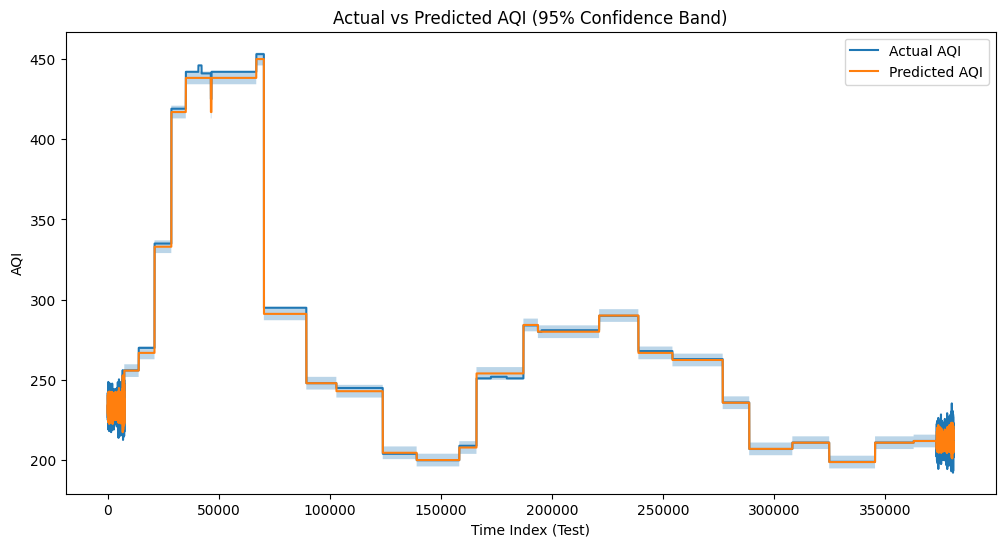

✅ Test MAE: 1.3519601761911673
✅ Test RMSE: 2.173731030581097
✅ Test R2: 0.9990250702880534
✅ Residual STD: 2.020016300468898


In [35]:
import matplotlib.pyplot as plt 
y_true = y_test.values
y_pred = pred_test

lower = np.clip(y_pred - 1.96 * residual_std, 0, 800)
upper = np.clip(y_pred + 1.96 * residual_std, 0, 800)

plt.figure(figsize=(12, 6))
plt.plot(y_true, label="Actual AQI")
plt.plot(y_pred, label="Predicted AQI")
plt.fill_between(range(len(y_pred)), lower, upper, alpha=0.3)
plt.title("Actual vs Predicted AQI (95% Confidence Band)")
plt.xlabel("Time Index (Test)")
plt.ylabel("AQI")
plt.legend()
plt.show()
print("✅ Test MAE:", mae)
print("✅ Test RMSE:", rmse)
print("✅ Test R2:", r2)
print("✅ Residual STD:", residual_std)

# 13) Save artifacts

In [36]:
import os, json, joblib

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

# 1) Core artifacts (UI needs these)
joblib.dump(final_model, os.path.join(MODEL_DIR, "best_model.pkl"))
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))
joblib.dump(FEATURES,os.path.join(MODEL_DIR, "feature_list.pkl"))

# 2) Metrics for UI top boxes + CI band
metrics = {
    "rmse": float(rmse),
    "r2": float(r2),
    "mae": float(mae),
    "residual_std": float(residual_std)
}
with open(os.path.join(MODEL_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

# 3) Tail for seeding (must include Time + city + location_id + FEATURES)
TAIL_OUT = os.path.join(MODEL_DIR, "recent_tail.csv")

extra_cols = []
if "Time" in df.columns: extra_cols.append("Time")
if "city" in df.columns: extra_cols.append("city")
if "location_id" in df.columns: extra_cols.append("location_id")

keep_cols = list(dict.fromkeys(extra_cols + FEATURES))  # unique
df[keep_cols].tail(20000).to_csv(TAIL_OUT, index=False)

print("✅ Saved:")
print("best_model.pkl")
print("scaler.pkl")
print("feature_list.pkl")
print("metrics.json")
print("recent_tail.csv")

✅ Saved:
best_model.pkl
scaler.pkl
feature_list.pkl
metrics.json
recent_tail.csv
